# Day 3 — Model Evaluation, Failure Analysis & Explainability

**Project:** AI Model Failure Detection & Explainability System  
**Objective:** Evaluate model performance, investigate misclassified predictions, and understand the factors influencing model decisions.

This notebook focuses on analyzing how the trained model behaves on unseen data. We evaluate model performance using standard metrics, detect misclassified cases, and perform detailed failure analysis to identify patterns where the model struggles.

To better understand the model’s decision-making process, SHAP explainability techniques are applied to reveal which features influence predictions the most. Additionally, model probability outputs are transformed into risk scores to quantify the likelihood of churn for each customer.

The insights obtained from this analysis help identify model weaknesses and highlight opportunities for future model improvements.

---

**Author:** Rishikesh Singh  
**Role:** Data Science Student  
**Project Stage:** Model Evaluation & Explainability (Day 3)  
**Tools:** Python, Scikit-learn, Pandas, SHAP, Matplotlib, Seaborn

## 1. Load Dataset and Trained Model

In this section we load:
- The dataset used for evaluation
- The trained machine learning pipeline from Day 2

The pipeline includes preprocessing steps and the trained model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

In [2]:
model = joblib.load("../models/baseline_pipeline.pkl")
print("Model loaded successfully")

Model loaded successfully


## 2. Prepare Features and Target

Separate the dataset into:

- Feature matrix (X)
- Target variable (y)

This allows the model to generate predictions for evaluation.

In [3]:
df = pd.read_csv("../data/dataset.csv")

df = df.drop(columns=['customerID'], errors='ignore')

X = df.drop(columns=['Churn'])
y = df['Churn']

In [6]:
from sklearn.preprocessing import LabelEncoder

cat_cols = X.select_dtypes(include=['object','string']).columns

le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col])

y = LabelEncoder().fit_transform(y)

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Generate Predictions

The trained model is used to generate:

- Predicted class labels
- Prediction probabilities

These probabilities will later be used to compute **risk scores** and analyze model confidence.

In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]


Failures: 363


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual,Predicted,Confidence,Failure
437,1,0,1,1,72,1,2,1,2,2,...,2,2,1,1,114.05,6196,0,0,0.097583,False
2280,0,1,0,0,8,1,2,1,0,0,...,2,0,1,1,100.15,6340,0,1,0.904663,True
2235,0,0,1,1,41,1,2,0,2,2,...,0,1,1,1,78.35,2796,0,0,0.189133,False
4460,1,0,1,0,18,1,0,1,0,0,...,0,0,0,2,78.20,862,0,1,0.577528,True
3761,0,0,1,0,72,1,2,0,2,2,...,2,2,1,1,82.65,4855,0,0,0.063937,False


## Create Prediction Results Table

A results dataframe is created containing:

- Actual values
- Predicted values
- Model confidence
- Failure indicator (misclassification)

This table will be used for further failure analysis.

In [ ]:

results = X_test.copy()
results["Actual"] = y_test
results["Predicted"] = y_pred
results["Confidence"] = y_prob

results["Failure"] = results["Actual"] != results["Predicted"]

print("Failures:", results["Failure"].sum())

results.head()

## Risk Score Generation

Model probability outputs are converted into **risk scores**.

The risk score represents the probability that a customer will churn.

For easier interpretation, customers are also categorized into:

- Low Risk
- Medium Risk
- High Risk

In [32]:
# Generate Risk Score
results["risk_score"] = y_prob

# Optional: create interpretable risk levels
results["risk_level"] = pd.cut(
    results["risk_score"],
    bins=[0, 0.3, 0.7, 1],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

results.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual,Predicted,Confidence,Failure,risk_score,risk_level
437,1,0,1,1,72,1,2,1,2,2,...,1,1,114.05,6196,0,0,0.097583,False,0.097583,Low Risk
2280,0,1,0,0,8,1,2,1,0,0,...,1,1,100.15,6340,0,1,0.904663,True,0.904663,High Risk
2235,0,0,1,1,41,1,2,0,2,2,...,1,1,78.35,2796,0,0,0.189133,False,0.189133,Low Risk
4460,1,0,1,0,18,1,0,1,0,0,...,0,2,78.20,862,0,1,0.577528,True,0.577528,Medium Risk
3761,0,0,1,0,72,1,2,0,2,2,...,1,1,82.65,4855,0,0,0.063937,False,0.063937,Low Risk


## Model Explainability using SHAP

SHAP (SHapley Additive exPlanations) is used to understand how features influence model predictions.

This analysis helps answer:

- Which features influence predictions the most?
- Which features contribute to incorrect predictions?
- How individual predictions are formed.

In [22]:
explainer = shap.Explainer(model.named_steps['model'], X_train)

In [23]:
sample_X = X_test.sample(200, random_state=42)

shap_values = explainer(sample_X)

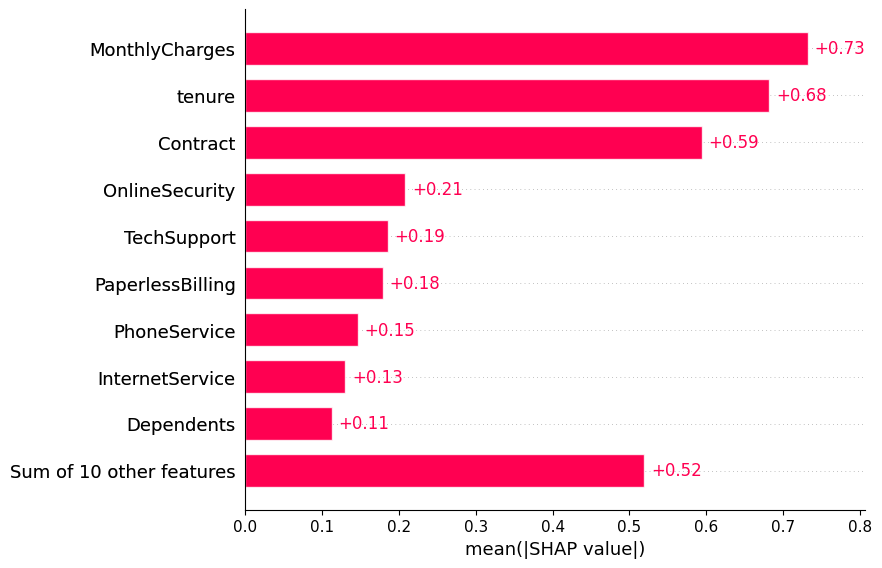

In [24]:
shap.plots.bar(shap_values)

## Global Feature Importance Analysis (SHAP)

The SHAP global importance analysis identifies the features that most strongly influence model predictions across the entire dataset.

### Key Observations

- **MonthlyCharges** is the most influential feature, indicating that customer pricing plays a dominant role in churn prediction.
- **tenure** is the second most important feature, suggesting that customer loyalty duration strongly impacts model decisions.
- **Contract type** also shows high importance, confirming that commitment length significantly affects predicted churn behaviour.
- Service-related features such as OnlineSecurity, TechSupport, and PaperlessBilling contribute moderately to predictions.
- The combined contribution of several smaller features remains substantial, indicating that the model incorporates multiple signals rather than relying on a single variable.

### Interpretation

The model primarily bases its predictions on customer cost, duration of relationship, and contract commitment. These features form the core decision structure used by the model when estimating churn probability.

### Implication of Failure Analysis.

Because the model heavily relies on MonthlyCharges, tenure, and Contract type, prediction errors are likely to occur in situations where these variables present ambiguous or conflicting patterns. For example, customers with high monthly charges but long tenure or those with short contracts but stable service usage may produce uncertain predictions, increasing the likelihood of model misclassification.

This insight provides an initial indication of which features should be investigated further when analyzing model failures.

/var/folders/rt/48gpknks5mlc888bjxc5dfx00000gn/T/ipykernel_1219/2960256480.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, sample_X)


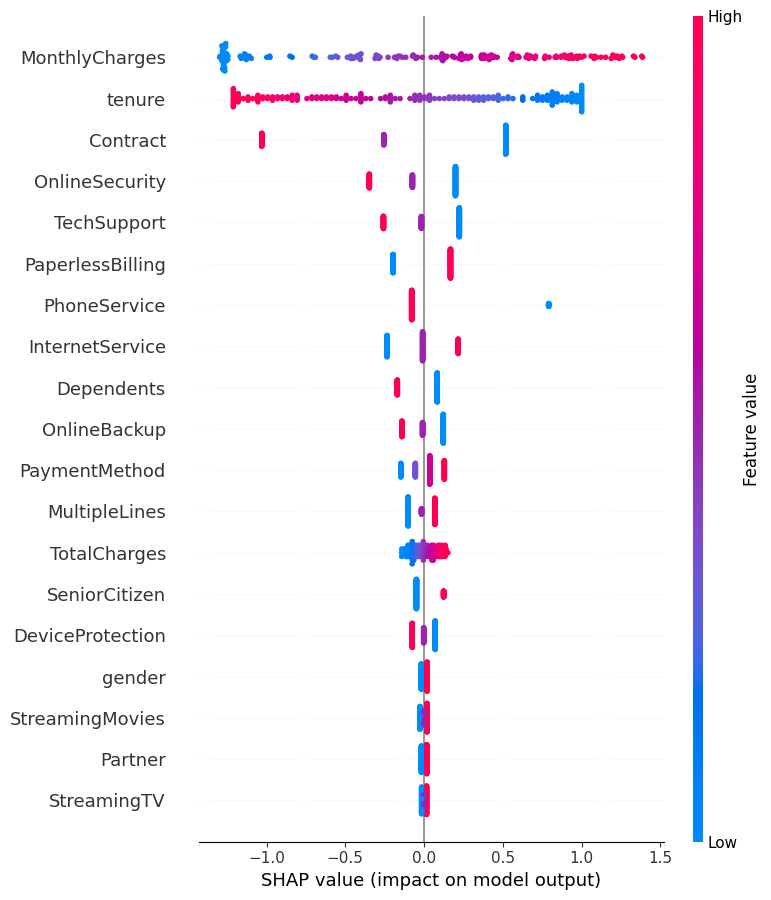

In [25]:
shap.summary_plot(shap_values, sample_X)

## SHAP Summary Analysis (Feature Behaviour)

The SHAP summary plot explains how individual feature values influence model predictions toward churn or non-churn outcomes.Unlike the global importance plot, this visualization reveals how feature values shift predictions in different directions across individual samples.

### Key Observations

- **MonthlyCharges:** Higher values push predictions toward churn, while lower values contribute toward non-churn predictions.
- **tenure:** Longer customer tenure strongly reduces churn probability, whereas shorter tenure increases churn risk.
- **Contract:** Contract type significantly influences predictions, indicating the importance of customer commitment duration.
- **OnlineSecurity and TechSupport:** Presence of these services shifts predictions toward customer retention.
- Several demographic and auxiliary features remain centered around zero SHAP value, suggesting limited influence on model decisions.

### Interpretation

The model’s decision behavior indicates that pricing pressure, customer loyalty duration, and contractual commitment form the primary structure of churn prediction. In general, high costs combined with low tenure increase predicted churn risk, while longer tenure and stronger service engagement contribute toward retention predictions.

### Implication for Failure Analysis

Because the model relies heavily on these variables, prediction errors may occur in situations where feature patterns conflict with typical churn behavior. For example:
+ Customers with high MonthlyCharges but long tenure
+ Customers with low tenure but strong service engagement
+ Customers whose contract type contradicts expected churn patterns

Such combinations may create ambiguous decision boundaries, increasing the likelihood of incorrect predictions.

Understanding these feature interactions helps identify conditions under which the model may fail, forming the basis for targeted failure analysis in the next stage.

/var/folders/rt/48gpknks5mlc888bjxc5dfx00000gn/T/ipykernel_1219/2477964511.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(failed_shap, failed_sample)


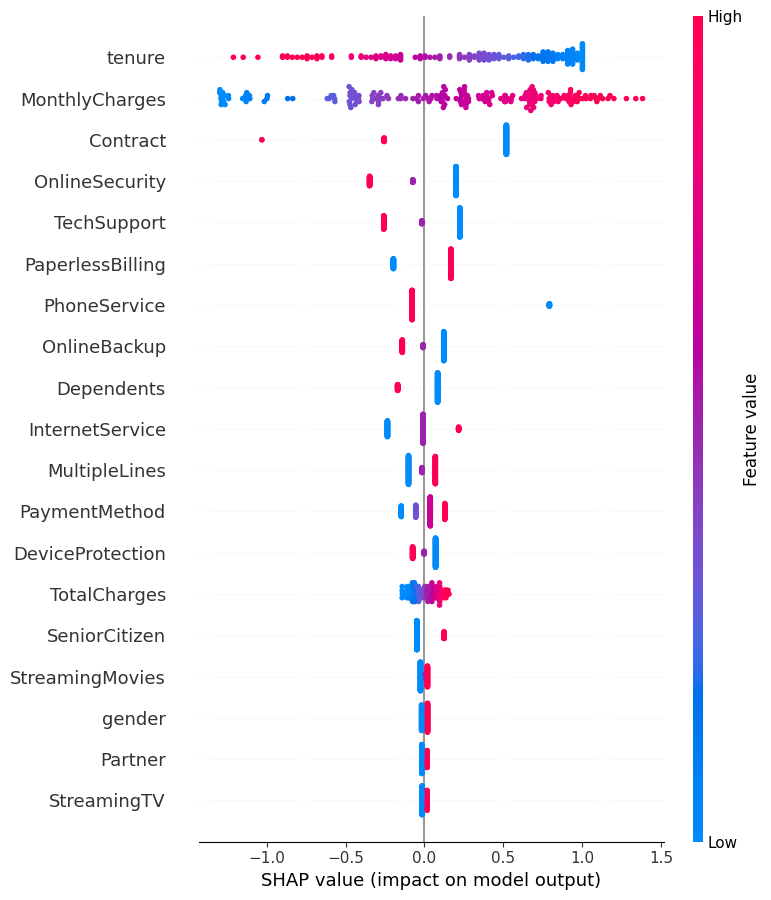

In [26]:
failed_indices = results[results["Failure"]].index

failed_sample = X_test.loc[failed_indices].sample(
    min(200, len(failed_indices)),
    random_state=42
)

failed_shap = explainer(failed_sample)

shap.summary_plot(failed_shap, failed_sample)

## Failure-Focused SHAP Interpretation

To better understand model errors, SHAP explanations were analyzed specifically for cases where the model predicted incorrectly.

### Key Observations:

+ The failure summary analysis shows that tenure has the strongest influence among misclassified cases.
+ Customers with low tenure appear frequently among incorrect predictions, indicating that the model struggles to accurately classify newer customers.
+ MonthlyCharges also contributes to several failure cases, particularly when high charges appear alongside conflicting signals such as longer tenure or stronger service engagement.
+ Contract-related features sometimes produce ambiguous patterns, where short-term contracts combined with otherwise stable service usage lead to uncertain predictions.

### Interpretation:

These observations suggest that model failures often occur in edge cases where important features provide conflicting signals. In particular, customers with short tenure but moderate or stable service usage may not follow typical churn patterns learned by the model.

Because tenure strongly influences predictions, situations where tenure conflicts with other churn indicators can create decision uncertainty, increasing the likelihood of incorrect predictions.

### Failure Insight:
The failure analysis reveals that the model is most vulnerable when:

+ Customers are new (low tenure) but do not show strong churn indicators.
+ Customers have high MonthlyCharges but long tenure, contradicting expected churn patterns.
+ Service engagement features (OnlineSecurity, TechSupport) suggest retention while pricing features suggest churn.

These patterns highlight the importance of investigating feature interactions and edge-case customer profiles when designing AI systems for churn prediction.

## Failure Detection (Misclassified Cases)

Prediction failures occur when:

Actual Value ≠ Predicted Value

These cases are extracted to analyze where the model struggles and identify patterns that lead to incorrect predictions.

In [27]:
# Separate failures and correct predictions
failures = results[results["Failure"] == True]
correct = results[results["Failure"] == False]

print("Total Test Samples:", len(results))
print("Failed Predictions:", len(failures))
print("Correct Predictions:", len(correct))

failures.head()

Total Test Samples: 1409
Failed Predictions: 363
Correct Predictions: 1046


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual,Predicted,Confidence,Failure
2280,0,1,0,0,8,1,2,1,0,0,...,2,0,1,1,100.15,6340,0,1,0.904663,True
4460,1,0,1,0,18,1,0,1,0,0,...,0,0,0,2,78.20,862,0,1,0.577528,True
5748,0,0,0,0,21,1,2,1,0,2,...,2,0,1,1,99.85,1599,0,1,0.840823,True
3568,0,0,0,0,21,1,0,1,0,2,...,2,0,1,0,99.15,1558,0,1,0.710885,True
2136,1,0,0,1,15,1,2,1,0,2,...,0,0,1,2,91.00,797,0,1,0.802245,True


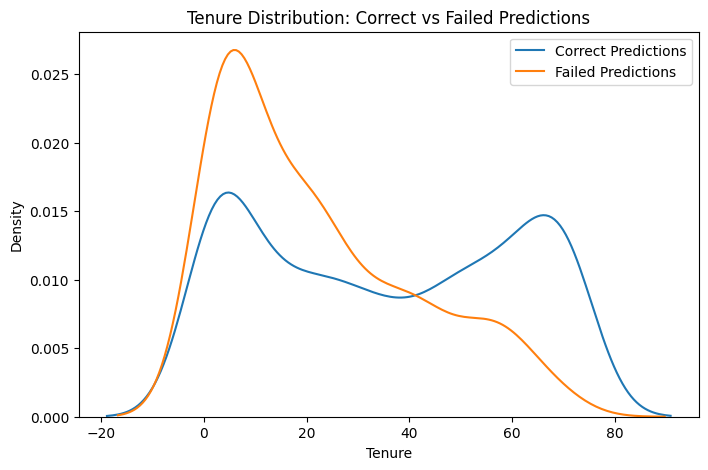

In [28]:
# Compare tenure distribution

plt.figure(figsize=(8,5))

sns.kdeplot(correct["tenure"], label="Correct Predictions")
sns.kdeplot(failures["tenure"], label="Failed Predictions")

plt.title("Tenure Distribution: Correct vs Failed Predictions")
plt.xlabel("Tenure")
plt.ylabel("Density")
plt.legend()

plt.show()

## Tenure Failure Analysis

The tenure distribution shows that most model failures occur among customers with low tenure. Newer customers appear to exhibit more ambiguous churn behavior, making them harder for the model to classify accurately.

In contrast, long-term customers show significantly higher prediction accuracy, suggesting that tenure provides a strong and reliable signal for churn prediction when the customer relationship has matured.

The mid-tenure range shows overlapping distributions between correct and failed predictions, indicating a potential decision boundary where the model experiences uncertainty.

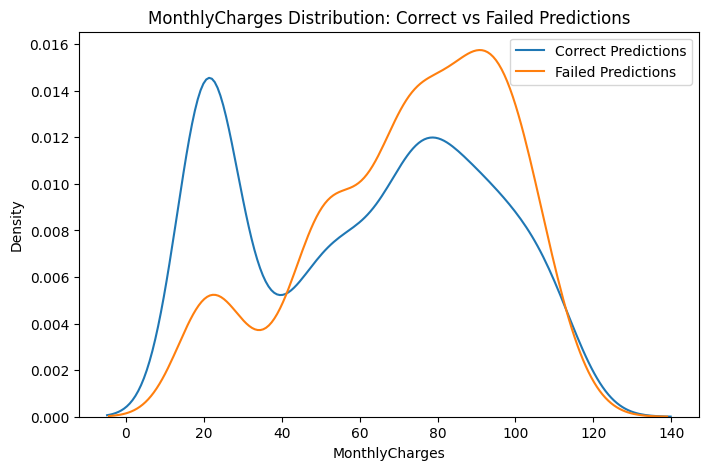

In [29]:
plt.figure(figsize=(8,5))

sns.kdeplot(correct["MonthlyCharges"], label="Correct Predictions")
sns.kdeplot(failures["MonthlyCharges"], label="Failed Predictions")

plt.title("MonthlyCharges Distribution: Correct vs Failed Predictions")
plt.xlabel("MonthlyCharges")
plt.ylabel("Density")
plt.legend()

plt.show()

## MonthlyCharges Failure Analysis

The distribution analysis shows that prediction failures increase for customers with higher monthly charges. While correct predictions peak at lower charge ranges (15–25), failure cases appear more frequently in the mid-to-high charge ranges (55–100).

This suggests that customers with higher pricing plans produce more ambiguous patterns for the model. Some high-paying customers remain loyal despite high costs, while others churn due to price sensitivity.

Additionally, overlapping regions around MonthlyCharges values of 40 and 120 
indicate areas where the model experiences higher uncertainty, likely due to 
conflicting feature signals.

## Feature Importance for Failed Predictions

To better understand model weaknesses, SHAP values are analyzed specifically for misclassified cases.

This reveals which features contribute most strongly to model errors.

In [30]:
import numpy as np

# Compute mean absolute SHAP importance for failed predictions
failure_importance = np.abs(failed_shap.values).mean(axis=0)

failure_feature_importance = pd.DataFrame({
    "Feature": failed_sample.columns,
    "Failure_SHAP_Importance": failure_importance
})

failure_feature_importance = failure_feature_importance.sort_values(
    by="Failure_SHAP_Importance",
    ascending=False
)

failure_feature_importance.head(10)

,Feature,Failure_SHAP_Importance
4,tenure,0.621339
17,MonthlyCharges,0.611360
14,Contract,0.495059
8,OnlineSecurity,0.224849
11,TechSupport,0.219418
15,PaperlessBilling,0.175148
5,PhoneService,0.138880
9,OnlineBackup,0.119380
3,Dependents,0.098286
7,InternetService,0.098001


## Visualization of Failure-Driving Features

A bar chart is used to visualize the top features contributing to prediction failures.

This helps identify patterns where the model struggles and where improvements may be required.

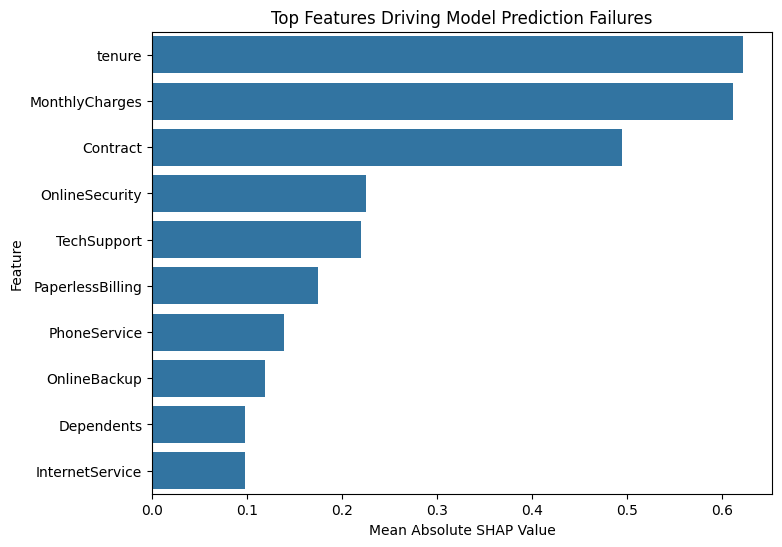

In [31]:
plt.figure(figsize=(8,6))

sns.barplot(
    x="Failure_SHAP_Importance",
    y="Feature",
    data=failure_feature_importance.head(10)
)

plt.title("Top Features Driving Model Prediction Failures")
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")

plt.show()

# Day 3 Conclusion: Failure Analysis

+ The failure analysis revealed that the model's prediction errors are primarily driven by a small set of influential features.

+ Tenure and MonthlyCharges emerged as the most significant contributors to incorrect predictions. Customers with low tenure and higher monthly charges often exhibit ambiguous behavior patterns that make classification more challenging for the model.

+ Contract type also plays an important role in prediction failures, indicating that customer commitment level strongly influences churn patterns.

+ Additional service-related features such as OnlineSecurity and TechSupport further contribute to uncertainty when their patterns conflict with other customer attributes.

+ These insights provide valuable understanding of where the model struggles and highlight areas where feature engineering or additional data could improve predictive performance.